In [ ]:
import pandas as pd


fname = "test1_copycopy_output.csv"
# fname = "test1_copycopy_Fonly_output.csv"
# fname = "test1_copycopy_O1n2_output.csv"
try:
    df = pd.read_csv(fname)
    print(df.to_string(index=False))
except FileNotFoundError:
    print(f"File not found: {fname}")
except Exception as e:
    print("Error reading file:", e)


                experiment  epoch  train_loss  test_accuracy
   resnet101_baseline_adam      0    0.310267          95.60
   resnet101_baseline_adam      1    0.094525          97.57
   resnet101_baseline_adam      2    0.109089          96.19
   resnet101_baseline_adam      3    0.108679          98.47
   resnet101_baseline_adam      4    0.049943          98.60
   resnet101_baseline_adam      5    0.042636          98.74
   resnet101_baseline_adam      6    0.043132          87.71
   resnet101_baseline_adam      7    0.078077          98.68
   resnet101_baseline_adam      8    0.045206          98.82
   resnet101_baseline_adam      9    0.081834          96.90
resnet101_baseline_rmsprop      0    0.501073          90.43
resnet101_baseline_rmsprop      1    0.135604          98.05
resnet101_baseline_rmsprop      2    0.107219          98.20
resnet101_baseline_rmsprop      3    0.113435          98.30
resnet101_baseline_rmsprop      4    0.101561          98.45
resnet101_baseline_rmspr

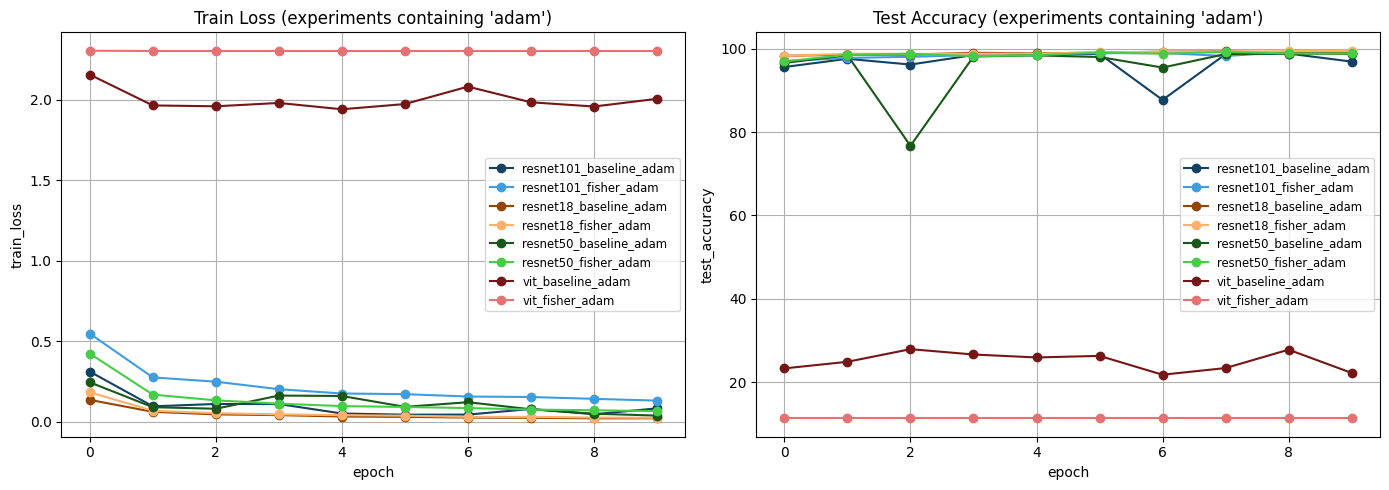

In [2]:

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys

def _adjust_lightness(color, factor):
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0.0, min(1.0, l * factor))
    return colorsys.hls_to_rgb(h, l, s)

def _first_token(experiment_name):
    parts = str(experiment_name).lower().split('_')
    return parts[0] if parts else str(experiment_name).lower()

def experiment_color(experiment_name, token_to_base):
    first_token = _first_token(experiment_name)
    is_baseline = 'baseline' in str(experiment_name).lower()

    base = token_to_base[first_token]
    if is_baseline:
        return _adjust_lightness(base, 0.55)  # darker for baseline
    return _adjust_lightness(base, 1.35)      # brighter for non-baseline

# filter experiments containing 'adam'
df_adam = df[df['experiment'].str.contains('adam', case=False, na=False)]

if df_adam.empty:
    print("No experiments with 'adam' found in 'experiment' column.")
else:
    token_order = sorted({str(name).split('_')[0].lower() for name in df_adam['experiment'].unique()})
    cmap = plt.get_cmap('tab10')
    token_to_base = {token: cmap(i % 10) for i, token in enumerate(token_order)}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, grp in df_adam.groupby('experiment'):
        color = experiment_color(name, token_to_base)
        axes[0].plot(grp['epoch'], grp['train_loss'], marker='o', label=name, color=color)
        axes[1].plot(grp['epoch'], grp['test_accuracy'], marker='o', label=name, color=color)

    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('train_loss')
    axes[0].set_title("Train Loss (experiments containing 'adam')")
    axes[0].legend(fontsize='small', loc='best')
    axes[0].grid(True)

    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('test_accuracy')
    axes[1].set_title("Test Accuracy (experiments containing 'adam')")
    axes[1].legend(fontsize='small', loc='best')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

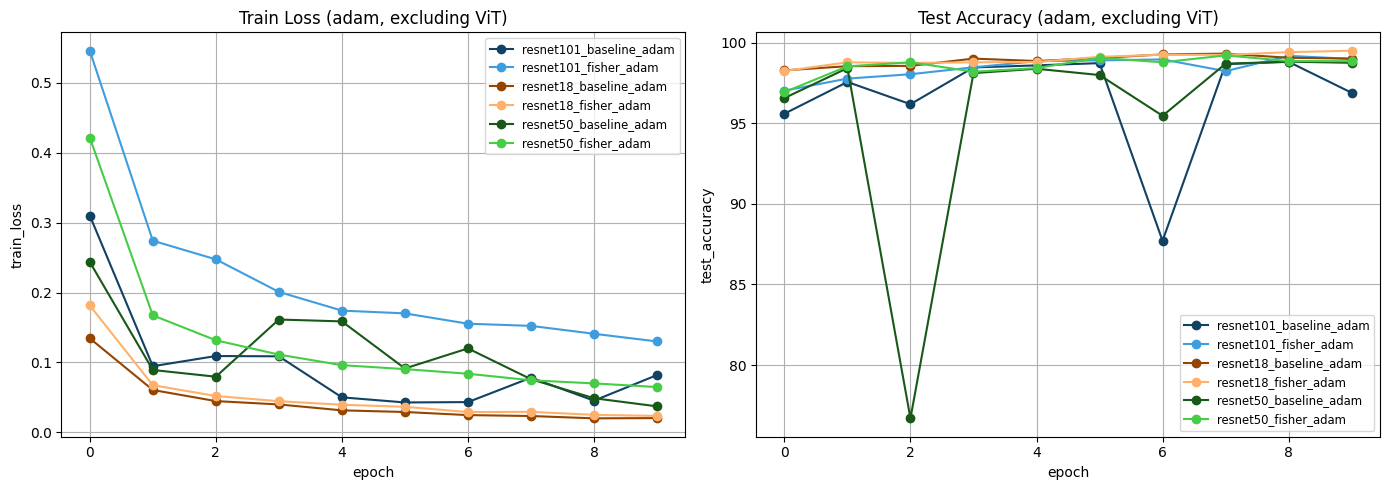

In [3]:

# filter experiments containing 'adam' but exclude any with 'vit'
df_adam_no_vit = df[
    df['experiment'].str.contains('adam', case=False, na=False) &
    ~df['experiment'].str.contains('vit', case=False, na=False)
]

if df_adam_no_vit.empty:
    print("No 'adam' experiments found after excluding ViT.")
else:
    token_order = sorted({_first_token(name) for name in df_adam_no_vit['experiment'].unique()})
    cmap = plt.get_cmap('tab10')
    token_to_base = {token: cmap(i % 10) for i, token in enumerate(token_order)}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, grp in df_adam_no_vit.groupby('experiment'):
        color = experiment_color(name, token_to_base)
        axes[0].plot(grp['epoch'], grp['train_loss'], marker='o', label=name, color=color)
        axes[1].plot(grp['epoch'], grp['test_accuracy'], marker='o', label=name, color=color)

    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('train_loss')
    axes[0].set_title("Train Loss (adam, excluding ViT)")
    axes[0].legend(fontsize='small', loc='best')
    axes[0].grid(True)

    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('test_accuracy')
    axes[1].set_title("Test Accuracy (adam, excluding ViT)")
    axes[1].legend(fontsize='small', loc='best')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


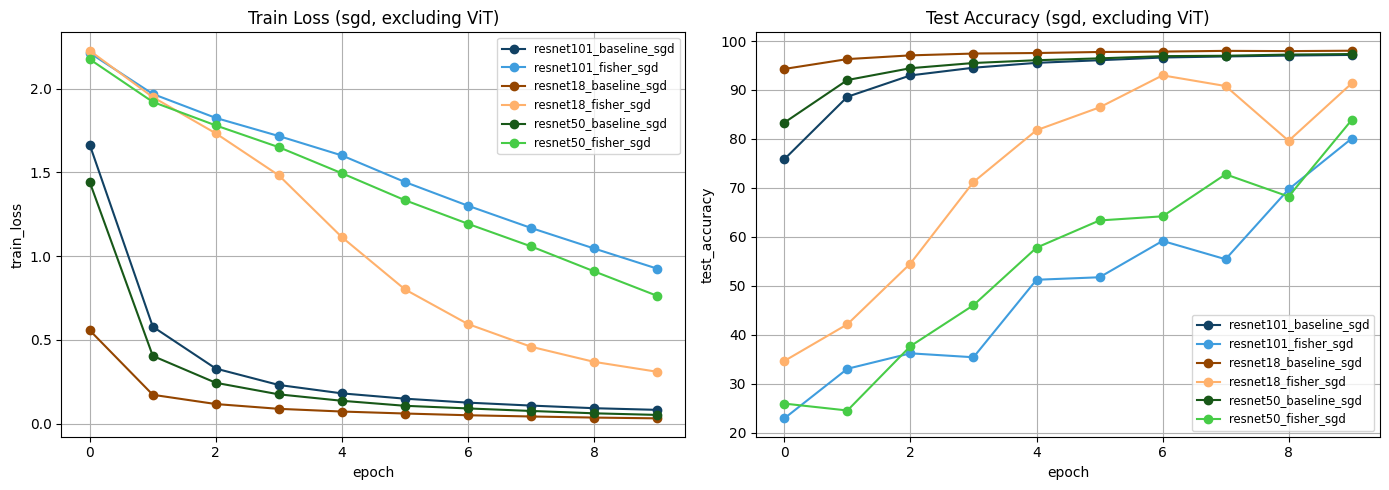

In [4]:

# filter experiments containing 'sgd' but exclude any with 'vit'
df_sgd_no_vit = df[
    df['experiment'].str.contains('sgd', case=False, na=False) &
    ~df['experiment'].str.contains('vit', case=False, na=False)
]

if df_sgd_no_vit.empty:
    print("No 'sgd' experiments found after excluding ViT.")
else:
    token_order = sorted({_first_token(name) for name in df_sgd_no_vit['experiment'].unique()})
    cmap = plt.get_cmap('tab10')
    token_to_base = {token: cmap(i % 10) for i, token in enumerate(token_order)}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, grp in df_sgd_no_vit.groupby('experiment'):
        color = experiment_color(name, token_to_base)
        axes[0].plot(grp['epoch'], grp['train_loss'], marker='o', label=name, color=color)
        axes[1].plot(grp['epoch'], grp['test_accuracy'], marker='o', label=name, color=color)

    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('train_loss')
    axes[0].set_title("Train Loss (sgd, excluding ViT)")
    axes[0].legend(fontsize='small', loc='best')
    axes[0].grid(True)

    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('test_accuracy')
    axes[1].set_title("Test Accuracy (sgd, excluding ViT)")
    axes[1].legend(fontsize='small', loc='best')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


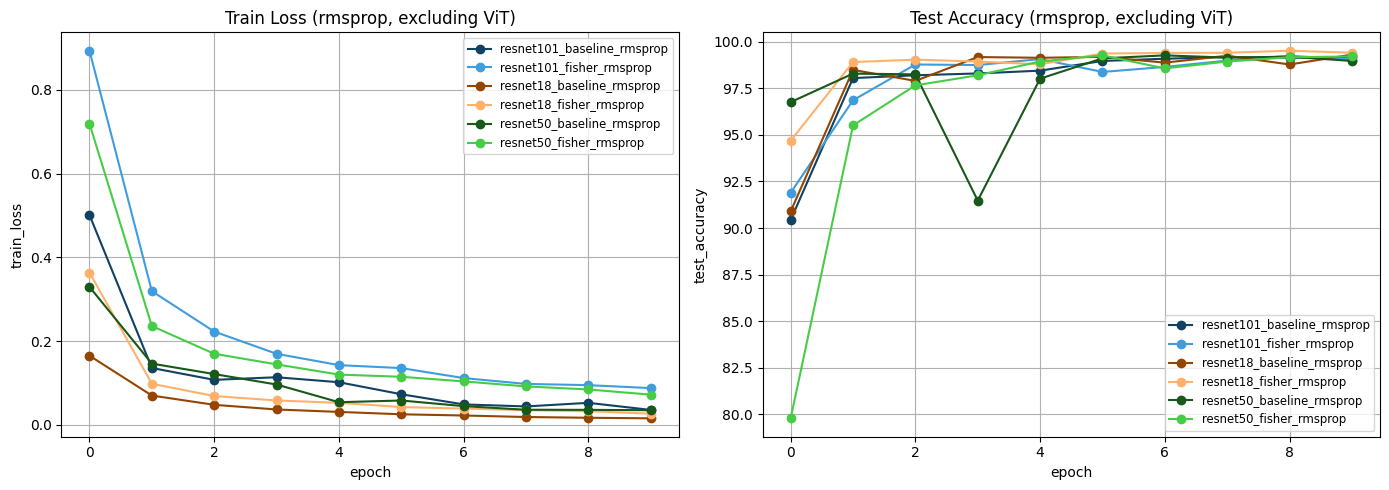

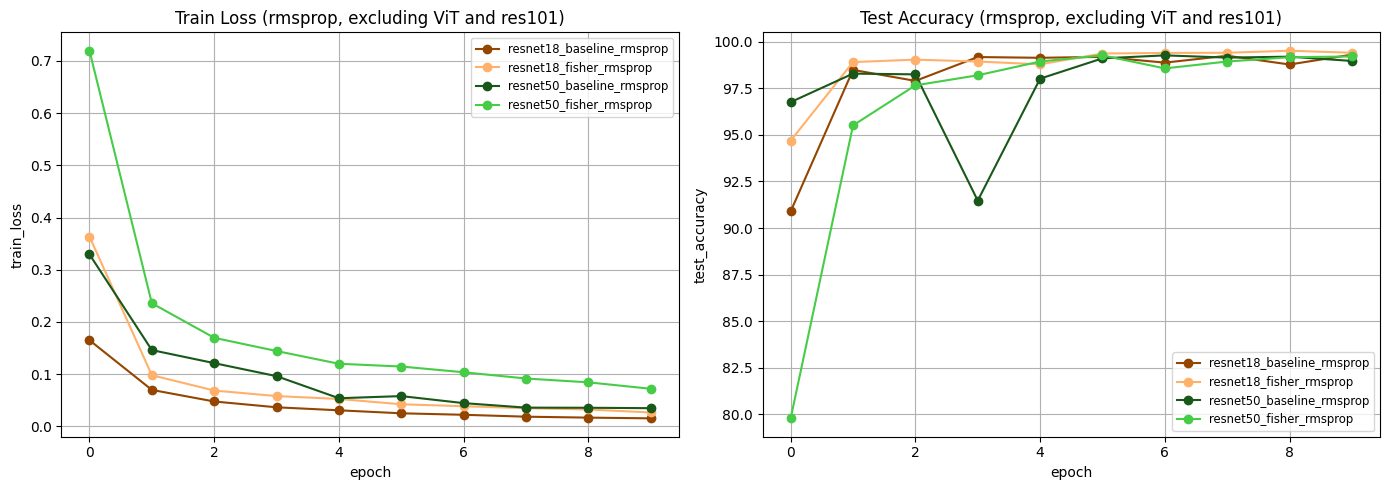

In [5]:

# filter experiments containing 'rmsprop' but exclude any with 'vit'
df_rmsprop_no_vit = df[
    df['experiment'].str.contains('rmsprop', case=False, na=False) &
    ~df['experiment'].str.contains('vit', case=False, na=False)
]

# additional filtered set (excluding res101)
df_rmsprop_no_vit_res101 = df[
    df['experiment'].str.contains('rmsprop', case=False, na=False) &
    ~df['experiment'].str.contains('vit', case=False, na=False) &
    ~df['experiment'].str.contains('resnet101', case=False, na=False)
]

if df_rmsprop_no_vit.empty and df_rmsprop_no_vit_res101.empty:
    print("No 'rmsprop' experiments found after excluding ViT.")
else:
    # shared color mapping across both dataframes (same experiment -> same color)
    all_names = set(df_rmsprop_no_vit['experiment'].unique()).union(
        set(df_rmsprop_no_vit_res101['experiment'].unique())
    )
    token_order = sorted({_first_token(name) for name in all_names})
    cmap = plt.get_cmap('tab10')
    token_to_base = {token: cmap(i % 10) for i, token in enumerate(token_order)}

    # Figure 1: df_rmsprop_no_vit
    if not df_rmsprop_no_vit.empty:
        fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
        for name, grp in df_rmsprop_no_vit.groupby('experiment'):
            color = experiment_color(name, token_to_base)
            axes1[0].plot(grp['epoch'], grp['train_loss'], marker='o', label=name, color=color)
            axes1[1].plot(grp['epoch'], grp['test_accuracy'], marker='o', label=name, color=color)

        axes1[0].set_xlabel('epoch')
        axes1[0].set_ylabel('train_loss')
        axes1[0].set_title("Train Loss (rmsprop, excluding ViT)")
        axes1[0].legend(fontsize='small', loc='best')
        axes1[0].grid(True)

        axes1[1].set_xlabel('epoch')
        axes1[1].set_ylabel('test_accuracy')
        axes1[1].set_title("Test Accuracy (rmsprop, excluding ViT)")
        axes1[1].legend(fontsize='small', loc='best')
        axes1[1].grid(True)

        plt.tight_layout()
        plt.show()
    else:
        print("df_rmsprop_no_vit is empty.")

    # Figure 2: df_rmsprop_no_vit_res101
    if not df_rmsprop_no_vit_res101.empty:
        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
        for name, grp in df_rmsprop_no_vit_res101.groupby('experiment'):
            color = experiment_color(name, token_to_base)
            axes2[0].plot(grp['epoch'], grp['train_loss'], marker='o', label=name, color=color)
            axes2[1].plot(grp['epoch'], grp['test_accuracy'], marker='o', label=name, color=color)

        axes2[0].set_xlabel('epoch')
        axes2[0].set_ylabel('train_loss')
        axes2[0].set_title("Train Loss (rmsprop, excluding ViT and res101)")
        axes2[0].legend(fontsize='small', loc='best')
        axes2[0].grid(True)

        axes2[1].set_xlabel('epoch')
        axes2[1].set_ylabel('test_accuracy')
        axes2[1].set_title("Test Accuracy (rmsprop, excluding ViT and res101)")
        axes2[1].legend(fontsize='small', loc='best')
        axes2[1].grid(True)

        plt.tight_layout()
        plt.show()
    else:
        print("df_rmsprop_no_vit_res101 is empty.")


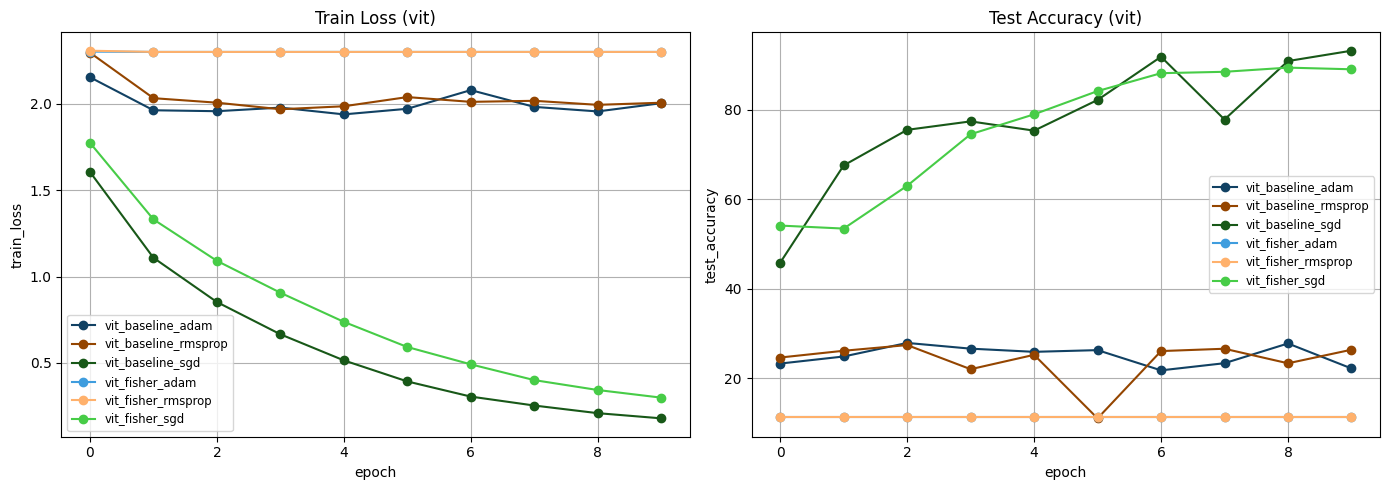

In [6]:

def _last_token(experiment_name):
    parts = str(experiment_name).lower().split('_')
    return parts[-1] if parts else str(experiment_name).lower()

def experiment_color_last_token(experiment_name, token_to_base):
    last_token = _last_token(experiment_name)
    is_baseline = 'baseline' in str(experiment_name).lower()

    base = token_to_base[last_token]
    if is_baseline:
        return _adjust_lightness(base, 0.55)  # darker for baseline
    return _adjust_lightness(base, 1.35)      # brighter for non-baseline

# filter experiments containing 'vit'
df_vit = df[
    df['experiment'].str.contains('vit', case=False, na=False)
]

if df_vit.empty:
    print("No 'vit' experiments found.")
else:
    token_order = sorted({_last_token(name) for name in df_vit['experiment'].unique()})
    cmap = plt.get_cmap('tab10')
    token_to_base = {token: cmap(i % 10) for i, token in enumerate(token_order)}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, grp in df_vit.groupby('experiment'):
        color = experiment_color_last_token(name, token_to_base)
        axes[0].plot(grp['epoch'], grp['train_loss'], marker='o', label=name, color=color)
        axes[1].plot(grp['epoch'], grp['test_accuracy'], marker='o', label=name, color=color)

    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('train_loss')
    axes[0].set_title("Train Loss (vit)")
    axes[0].legend(fontsize='small', loc='best')
    axes[0].grid(True)

    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('test_accuracy')
    axes[1].set_title("Test Accuracy (vit)")
    axes[1].legend(fontsize='small', loc='best')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()



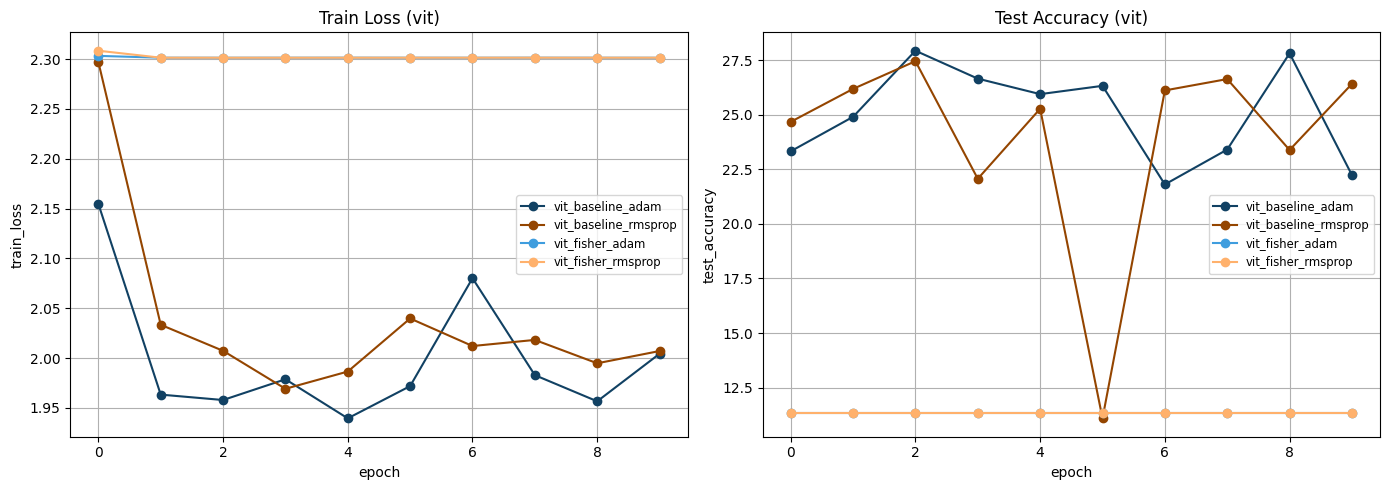

In [7]:


# filter experiments containing 'vit'
df_vit = df[
    df['experiment'].str.contains('vit', case=False, na=False) &
    ~df['experiment'].str.contains('sgd', case=False, na=False)
]

if df_vit.empty:
    print("No 'vit' experiments found.")
else:
    token_order = sorted({_last_token(name) for name in df_vit['experiment'].unique()})
    cmap = plt.get_cmap('tab10')
    token_to_base = {token: cmap(i % 10) for i, token in enumerate(token_order)}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, grp in df_vit.groupby('experiment'):
        color = experiment_color_last_token(name, token_to_base)
        axes[0].plot(grp['epoch'], grp['train_loss'], marker='o', label=name, color=color)
        axes[1].plot(grp['epoch'], grp['test_accuracy'], marker='o', label=name, color=color)

    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('train_loss')
    axes[0].set_title("Train Loss (vit)")
    axes[0].legend(fontsize='small', loc='best')
    axes[0].grid(True)

    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('test_accuracy')
    axes[1].set_title("Test Accuracy (vit)")
    axes[1].legend(fontsize='small', loc='best')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


